In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import raza_stats as rs

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import OrderedDict





In [2]:
df = pd.read_csv(r"C:\Salary-Prediction\data\raw\student_placement_prediction_dataset_2026.csv")

In [3]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [4]:
df.tail()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,...,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

In [6]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [7]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='str')

In [8]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [9]:
df.isna().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop('student_id', axis=1, inplace=True)

In [12]:
corr_matrix = df.corr(numeric_only=True)

# Check correlation with target column
corr_matrix['salary_package_lpa'].sort_values(ascending=False)

salary_package_lpa           1.000000
internships_count            0.114183
coding_skill_score           0.108336
cgpa                         0.076077
projects_count               0.059395
mock_interview_score         0.044840
logical_reasoning_score      0.035370
communication_skill_score    0.031718
aptitude_score               0.030821
leadership_score             0.021923
extracurricular_score        0.020219
github_repos                 0.005065
linkedin_connections         0.003657
hackathons_participated      0.000717
age                          0.000638
study_hours_per_day         -0.001530
certifications_count        -0.003444
sleep_hours                 -0.004402
attendance_percentage       -0.007694
backlogs                    -0.080119
Name: salary_package_lpa, dtype: float64

In [13]:
columns_del = [
    'backlogs',
    'attendance_percentage',
    'sleep_hours',
    'certifications_count',
    'study_hours_per_day',
    'hackathons_participated',
    'linkedin_connections',
    'extracurricular_score',
    'leadership_score'
]


for col in columns_del:
    df.drop(columns=col,inplace=True)


In [14]:
df.columns

Index(['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count',
       'projects_count', 'coding_skill_score', 'aptitude_score',
       'communication_skill_score', 'logical_reasoning_score', 'github_repos',
       'mock_interview_score', 'volunteer_experience', 'placement_status',
       'salary_package_lpa'],
      dtype='str')

In [ ]:
num_columns = df.select_dtypes(exclude='object').columns
cat_columns = df.select_dtypes(include='object').columns

num_stats = []

q1 = df[num_columns].quantile(0.25)
q3 = df[num_columns].quantile(0.75)
iqr = q3 - q1
lw = q1 - 1.5*iqr
uw = q3 + 1.5*iqr
outlier_count = ((df[num_columns] < lw) | (df[num_columns] > uw)).sum()
outlier_percentage = (outlier_count/len(df))*100

for i in num_columns:
    num_stats = OrderedDict({
        'Feature' : i,
        'Count' : df[i].count(),
        'Mean' : df[i].mean(),
        'Median' : df[i].median(),
        'Std' : df[i].
    })

print(outlier_count)
print(outlier_percentage)

age                             0
cgpa                          361
internships_count            6565
projects_count               1176
coding_skill_score            341
aptitude_score                355
communication_skill_score     326
logical_reasoning_score       362
github_repos                 2163
mock_interview_score          399
salary_package_lpa              0
dtype: int64
age                          0.000
cgpa                         0.361
internships_count            6.565
projects_count               1.176
coding_skill_score           0.341
aptitude_score               0.355
communication_skill_score    0.326
logical_reasoning_score      0.362
github_repos                 2.163
mock_interview_score         0.399
salary_package_lpa           0.000
dtype: float64


C:\Users\RAZA\AppData\Local\Temp\ipykernel_21384\2643200801.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include='object').columns


In [36]:
rs.cal_stats('Age : ' , df['age'])

Age : 
Total Sum 2100574
Total Count 100000
Minimum 18
Maximum 24
Range 6
Average 21.01
Median 21.0
Mode ModeResult(mode=np.int64(21), count=np.int64(14406))
Q1 19.0
Q3 23.0
IQR 4.0
Lower Whisker 13.0
Upper Whisker 29.0
Variance 3.9982070523999997
Standard Deviation 1.9995517128596598
Skewness -0.005507366812758214
Kurtosis -1.2494272263410138


age


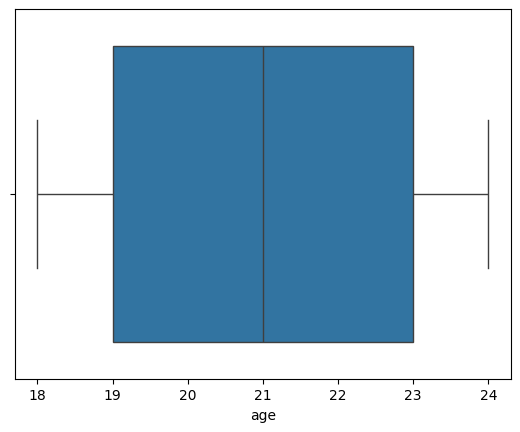

gender


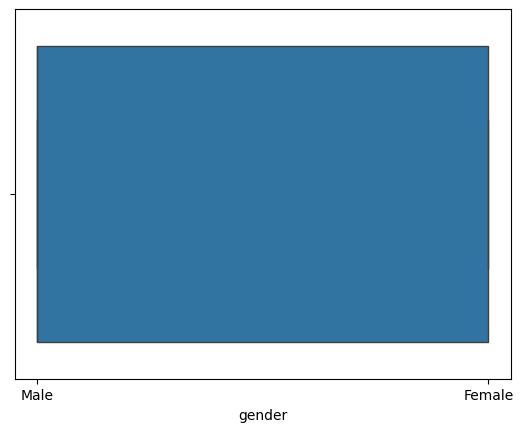

cgpa


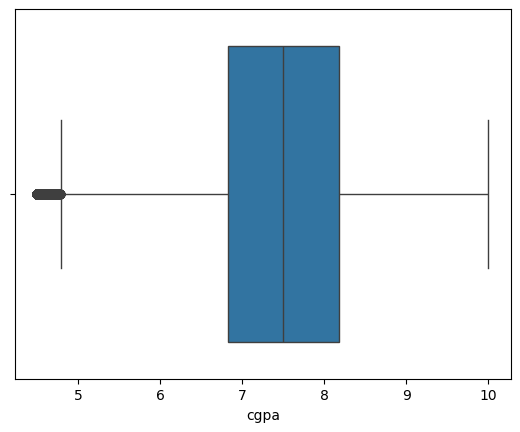

branch


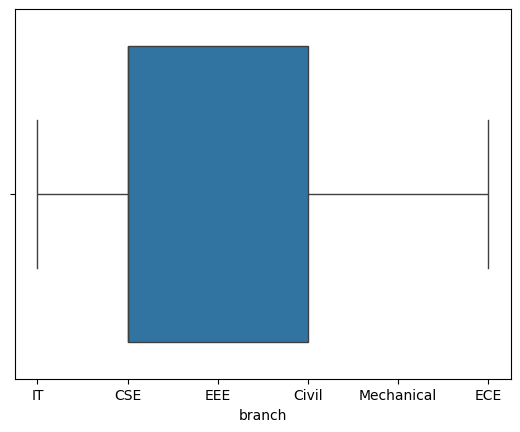

college_tier


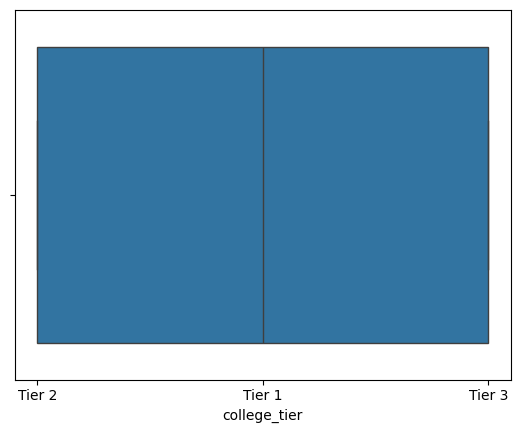

internships_count


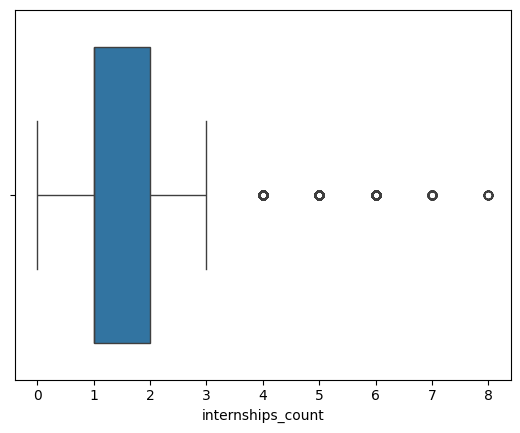

projects_count


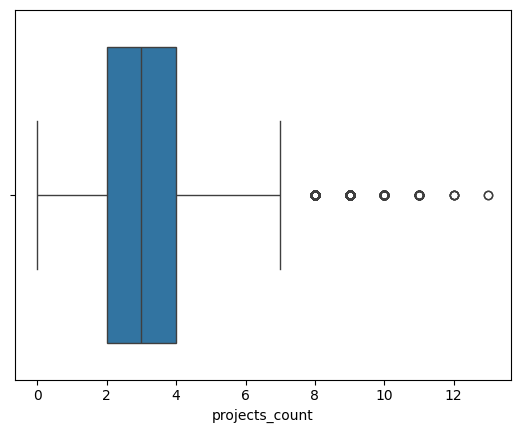

coding_skill_score


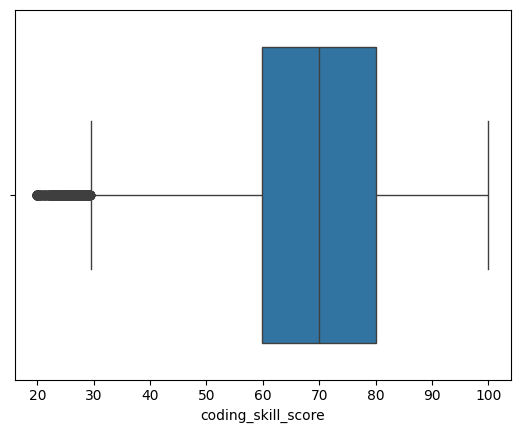

aptitude_score


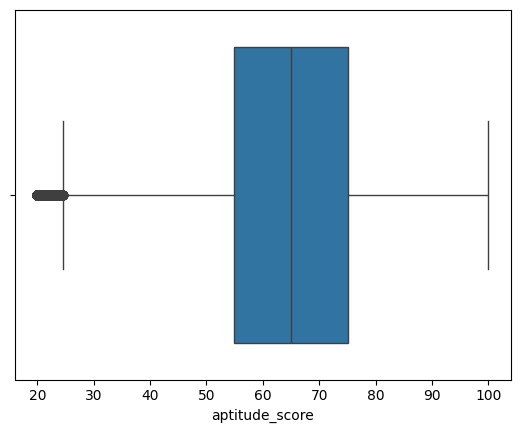

communication_skill_score


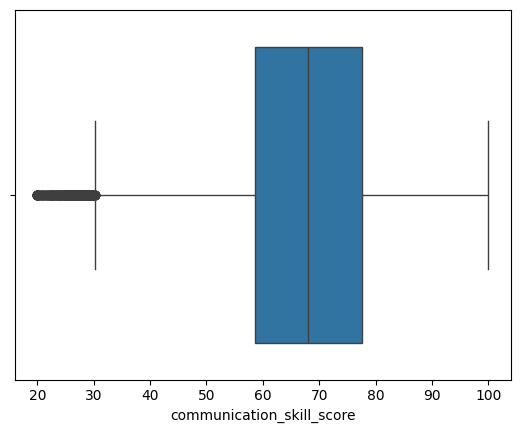

logical_reasoning_score


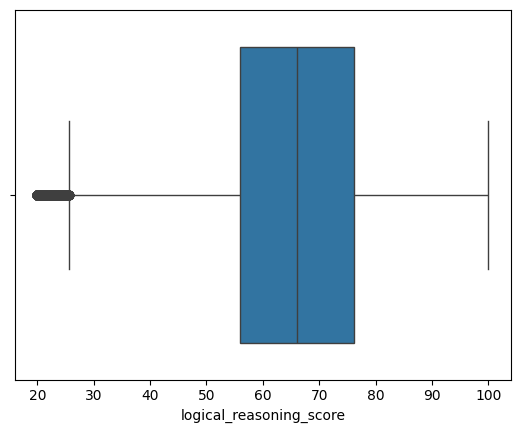

github_repos


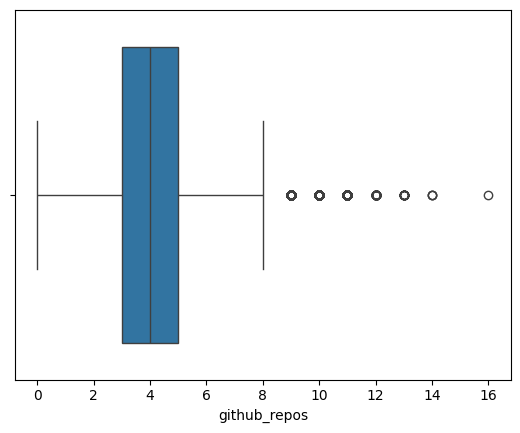

mock_interview_score


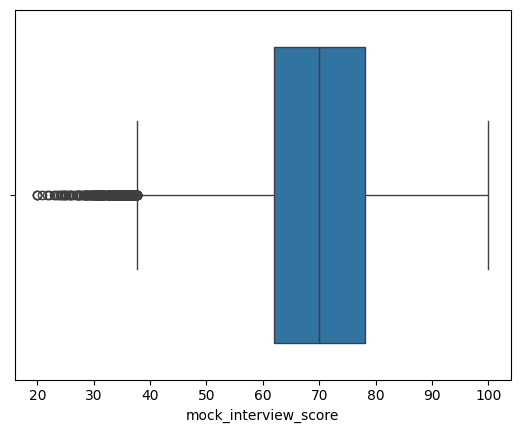

volunteer_experience


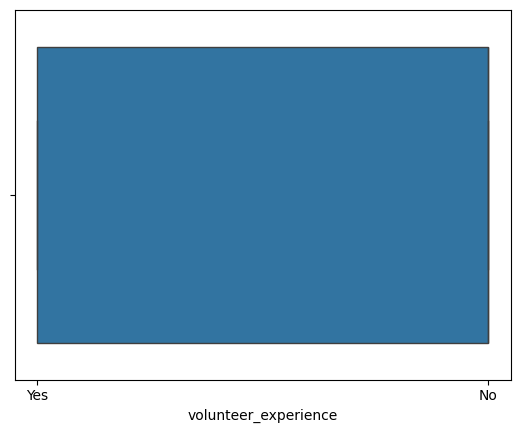

placement_status


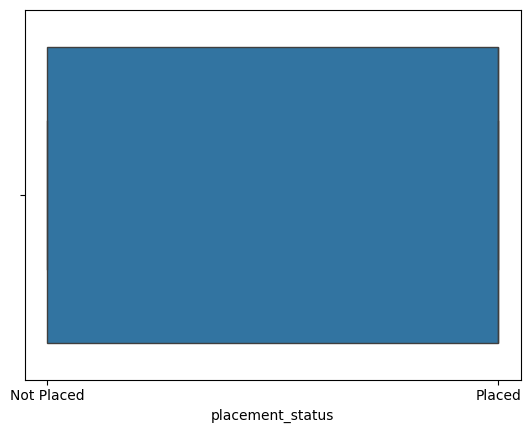

salary_package_lpa


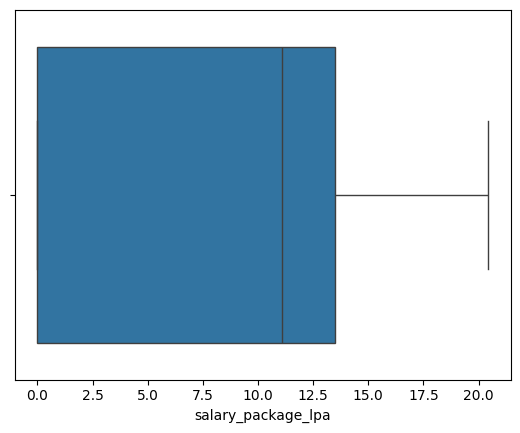

In [15]:
for col_name in df:
    print(col_name)
    sns.boxplot(df,x=col_name)
    plt.show()

In [16]:
df = df.drop(df[df['salary_package_lpa'] == 0].index)
(df['salary_package_lpa']==0).sum()

np.int64(0)

In [ ]:
x = df.drop('salary_package_lpa',axis=1)
y = df['salary_package_lpa']

x_train, x_test,y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

num_cols = x_train.select_dtypes(include= np.number).columns 
cat_cols = x_train.select_dtypes(include = 'object').columns

preprocessor = ColumnTransformer(
    transformers= [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ]
)

C:\Users\RAZA\AppData\Local\Temp\ipykernel_6708\2463535297.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(include = 'object').columns


In [ ]:
models = {
    'linear regression' : LinearRegression(),
    'ridge' : Ridge(),
    'lasso' : Lasso(),
    'elasticnet' : ElasticNet(),
    'decision tree' : DecisionTreeRegressor(),
    'random forest' : RandomForestRegressor(),
    'SVR' : SVR(),
    'Kneighbor' : KNeighborsRegressor(),
    'XGB' : XGBRegressor
}

In [23]:
base_results = {}

for name, regressor in models.items():

    pipeline = Pipeline([
        ('preprocessor' , preprocessor,
         'regressor' , regressor)
    ])

    pipeline.fit(x_train,y_train)
    y_pred = pipeline.predict(x_test)
    
    r2 = r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test,y_pred)
    base_results[name] = {
        'R2 Score' : r2,
        'RMSE' : rmse,
        'MAE' : mae
    }

    print(f'{name}')
    print(f'R2 : {r2:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print(f'MAE : {mae:.4f}')
    print('-'*40)

ValueError: too many values to unpack (expected 2)

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print(results_df)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

lr_params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lr_grid.fit(x_train, y_train)

best_lr = lr_grid.best_estimator_

print("Best Linear Params:", lr_grid.best_params_)

In [ ]:
#from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)